## Figure 3: Argo Float Pathways and Vertical Temperature Structure

**Purpose:** Generate Figure 3 of the paper.

**Description:**
Figure 3 shows (a) Argo float pathways with the color indicating dates of the profiles. The corresponding observed vertical temperature structure (b) along the western route through the Makassar Strait and (c) within the Banda Sea. The black and blue lines in (b) and (c) represent the depth of the 27 ◦C and 20 ◦C isotherms, respectively.

**Inputs:**
- `argo1_5903451.nc` — Argo float profiles, Makassar Strait route
- `argo2_6901746.nc` — Argo float profiles, Banda Sea

In [1]:
import xarray as xr 
import numpy as np 
import pandas as pd
import cartopy.crs as ccrs 
import cartopy.feature as cfeature
import matplotlib as mpl
from matplotlib import rcParams
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle

from shapely.geometry import LineString
from shapely.ops import unary_union
import regionmask
from shapely.geometry import Polygon 
from shapely.ops import unary_union
import warnings
import logging
plt.rcParams['font.size'] = 17

In [2]:
import os
os.chdir('/g/data/er50/sb4233/Scripts/Indonesian-seas-SST-variability_JGR-Oceans/') # set the path to working directory

In [3]:
warnings.filterwarnings('ignore')
mpl.rcParams['text.latex.preamble'] = r'\usepackage[utf8]{inputenc}'
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
logging.getLogger('matplotlib').setLevel(logging.ERROR)
rcParams.update({
    'text.usetex': True,            
    'font.family': 'Palatino Latino',         
    'font.serif': ['Palatino Latino'],  
    'text.latex.preamble': r'\usepackage{amsmath}'  
})

## Datasets

In [4]:
ds  = xr.open_dataset('./data/argo1_5903451.nc')
ds1 = xr.open_dataset('./data/argo2_6901746.nc')

In [5]:
WR_temp = ds.TEMP.rename({'N_PROF': 'Time'}).assign_coords(Time=('Time', ds.TIME.data))
Banda_temp = ds1.TEMP.rename({'N_PROF': 'Time'}).assign_coords(Time=('Time', ds1.TIME.data))

## Figure 3:

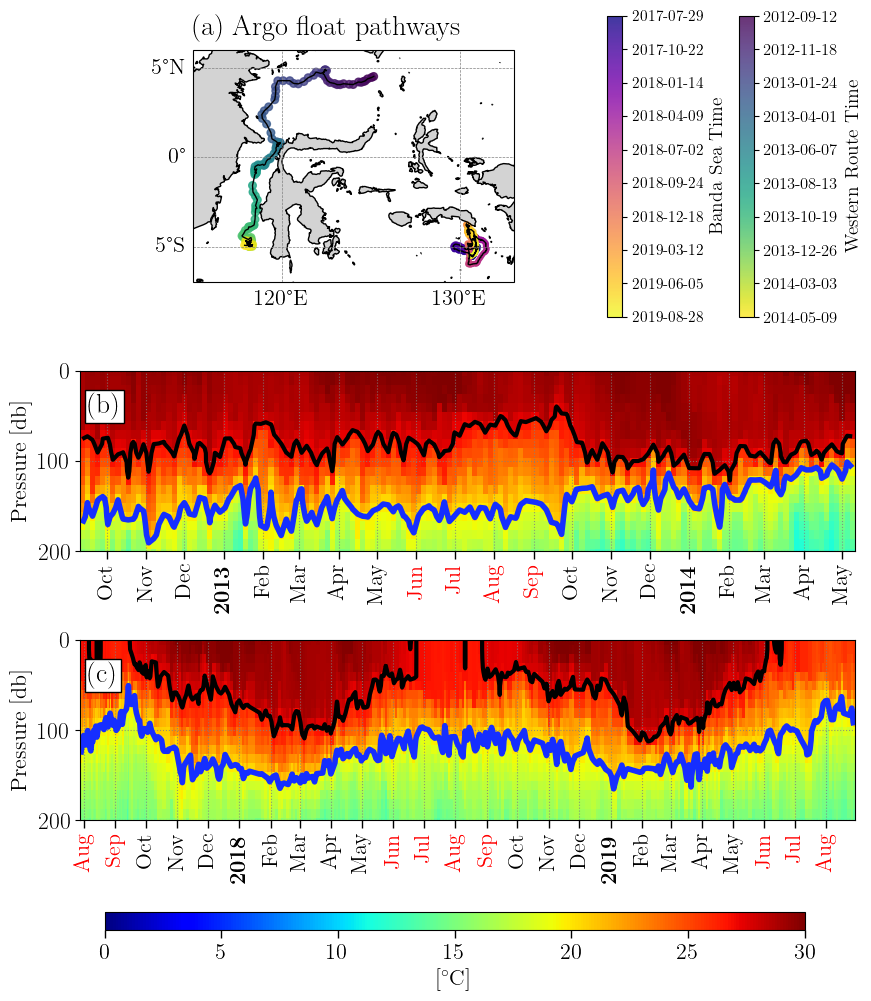

In [6]:
datetime_series = pd.to_datetime(ds.TIME.data, unit='s')
datetime_series1 = pd.to_datetime(ds1.TIME.data, unit='s')
longitude = ds.LONGITUDE.data
latitude = ds.LATITUDE.data
longitude1 = ds1.LONGITUDE.data
latitude1 = ds1.LATITUDE.data

fig = plt.figure(figsize=(10, 10))
gs = gridspec.GridSpec(3, 1, height_ratios=[1.8, 1.4, 1.4], hspace=0.45, figure=fig)

# -------- PLOT 1 (Top: map) --------
ax1 = fig.add_subplot(gs[0], projection=ccrs.PlateCarree())
ax1.coastlines(resolution='10m')
ax1.add_feature(cfeature.LAND, facecolor='lightgray')

sc1 = ax1.scatter(
    longitude, latitude,
    c=datetime_series.astype('int64') // 10**9,
    cmap='viridis', s=30, label='Eastern Route', alpha=0.8
)
ax1.plot(longitude, latitude, color='k', linestyle='-', linewidth=1)

sc2 = ax1.scatter(
    longitude1, latitude1,
    c=datetime_series1.astype('int64') // 10**9,
    cmap='plasma', s=10, label='Banda Sea', alpha=0.8
)
ax1.plot(longitude1, latitude1, color='k', linestyle='-', linewidth=1)

cbar1 = plt.colorbar(sc1, ax=ax1, orientation='vertical', shrink=1.3, pad=0.05)
cbar1.set_label(r'\text{Western Route Time}', fontsize=14)
tick_positions1 = np.linspace(datetime_series.min().timestamp(), datetime_series.max().timestamp(), 10)
cbar1.set_ticks(tick_positions1)
cbar1.set_ticklabels([pd.to_datetime(t, unit='s').strftime('%Y-%m-%d') for t in tick_positions1])
cbar1.ax.tick_params(labelsize=12)
cbar1.ax.invert_yaxis()

cbar2 = plt.colorbar(sc2, ax=ax1, orientation='vertical', shrink=1.3, pad=0.15)
cbar2.set_label(r'\text{Banda Sea Time}', fontsize=14)
tick_positions2 = np.linspace(datetime_series1.min().timestamp(), datetime_series1.max().timestamp(), 10)
cbar2.set_ticks(tick_positions2)
cbar2.set_ticklabels([pd.to_datetime(t, unit='s').strftime('%Y-%m-%d') for t in tick_positions2])
cbar2.ax.tick_params(labelsize=11)
cbar2.ax.invert_yaxis()

ax1.set_extent([115, 133, 6, -7], crs=ccrs.PlateCarree())
gl = ax1.gridlines(draw_labels=True, crs=ccrs.PlateCarree(),
                   linestyle='--', linewidth=0.5, color='gray')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 16, 'color': 'black'}
gl.ylabel_style = {'size': 16, 'color': 'black'}
gl.ylocator = mticker.FixedLocator([-5, 0, 5])
gl.xlocator = mticker.FixedLocator([120, 130])
ax1.set_title('(a) Argo float pathways', loc='left', y=1.03)

# -------- PLOTS 2 & 3 (Middle and Bottom) --------
levels = np.linspace(0, 30, 101)
ticks = np.linspace(0, 30, 7)
c_level = [27.0, 28.0]
c_20 = 20.0

bottom_axes = []
for i, (data, title) in enumerate(zip(
        [WR_temp, Banda_temp],
        ['(b)', '(c)'])):
    ax = fig.add_subplot(gs[i + 1])
    bottom_axes.append(ax)
    pc = ax.pcolormesh(data.TIME, data.PRES_INTERPOLATED, data.transpose(),
                       cmap='jet', vmin=0, vmax=30)
    ax.contour(data.TIME, data.PRES_INTERPOLATED, data.transpose(),
               levels=[c_level[0]], colors='k', linewidths=3)
    ax.contour(data.TIME, data.PRES_INTERPOLATED, data.transpose(),
               levels=[c_20], colors='xkcd:vivid blue', linewidths=4)
    ax.set_title(r'\text{' + title + '}', fontsize=20, loc='left', y=0.72, x=0.01,
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='square,pad=0.1', alpha=1))
    
    ax.grid(True, linestyle=':', color='grey', alpha=0.8)
    ax.set_ylim(0, 200)
    ax.invert_yaxis()
    ax.set_ylabel(r'\text{Pressure [db]}', fontsize=16)

for ax in bottom_axes:
    start = pd.to_datetime(ax.get_xlim()[0], unit='D', origin='unix')
    end = pd.to_datetime(ax.get_xlim()[1], unit='D', origin='unix')
    months = pd.date_range(start=start, end=end, freq='MS')
    ax.set_xticks(months)
    labels = []
    for d in months:
        label = d.strftime(r'\textbf{%Y}') if d.month == 1 else d.strftime('%b')
        color = 'red' if d.month in [6, 7, 8, 9] else 'black'
        labels.append(plt.Text(text=label, color=color))
    ax.set_xticklabels([t.get_text() for t in labels], rotation=90, fontsize=16)
    for tick, label in zip(ax.get_xticklabels(), labels):
        tick.set_color(label.get_color())
    ax.tick_params(axis='x', which='major', length=6, width=1, rotation=90)

cbar_ax = fig.add_axes([0.15, 0, 0.7, 0.018])
cbar = fig.colorbar(pc, cax=cbar_ax, orientation='horizontal', ticks=ticks)
cbar.set_label(r'[$^\circ$C]', fontsize=16)
cbar.ax.tick_params(length=6, width=1, labelsize=16)

#plt.savefig("./figures/fig3.png", dpi=200, bbox_inches='tight', facecolor='white')